# 11. Analisis integrador ejecutivo

## Priorizacion de oportunidades inmobiliarias para una estrategia de flip

Este notebook consolida los resultados tecnicos del proyecto en un embudo de decision:

1. **Barrio:** identificar zonas donde conviene concentrar la busqueda.
2. **Propiedad:** ordenar avisos con descuento relativo y condiciones favorables.
3. **Validacion:** indicar que debe verificarse antes de comprometer capital.

El objetivo no es estimar ni garantizar ROI real. Los datos contienen precios publicados, no precios de cierre, y no incluyen costos de obra, negociacion, impuestos, comisiones ni tiempo de reventa. El resultado es un sistema de priorizacion para mejorar la calidad de las oportunidades que pasan a due diligence.

## 1. Problema y propuesta de valor

Un inversor tipo *flipper* debe revisar muchas publicaciones con informacion incompleta y precios poco comparables. El proyecto reduce ese universo mediante evidencia:

- compara propiedades equivalentes por barrio, tipo y ambientes;
- incorpora estado, profundidad de mercado y accesibilidad;
- diferencia zonas por precio, stock mejorable y perfil comercial;
- utiliza un modelo de tasacion como segunda opinion, no como precio de reventa;
- entrega rankings explicables para decidir donde investigar primero.

In [1]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_INTERIM = ROOT / "data" / "interim"

CLEAN_PATH = DATA_PROCESSED / "Argenprop_limpio.csv"
FINAL_PATH = DATA_PROCESSED / "Argenprop_limpio_con_indices.csv"

df = pd.read_csv(FINAL_PATH, encoding="utf-8-sig", low_memory=False)
print(f"Dataset final: {df.shape[0]:,} propiedades x {df.shape[1]:,} variables")
print(f"Fuente: {FINAL_PATH.relative_to(ROOT)}")

Dataset final: 7,245 propiedades x 63 variables
Fuente: data\processed\Argenprop_limpio_con_indices.csv


## 2. Datos y trazabilidad

La base final surge de publicaciones de departamentos en venta en CABA obtenidas de Argenprop. El pipeline agrega geocodificacion, barrio, comuna, transporte, servicios urbanos, limpieza, imputacion, clusters e indices sinteticos. Las fuentes geoespaciales son datos abiertos del GCBA y OpenStreetMap/Overpass.

Las variables prefijadas distinguen su origen:

- `original_`: dato extraido del aviso;
- `imputada_`: dato completado o transformado durante limpieza;
- `enriquecida_`: dato geoespacial externo;
- `sintetica_`: cluster, score o indice calculado.

In [2]:
datasets = [
    ("Crudo", ROOT / "data" / "raw" / "argenprop_1776007342.tsv", "\t"),
    ("Geocodificado", DATA_INTERIM / "Argenprop_Lat_Lon.tsv", "\t"),
    ("Enriquecido", DATA_INTERIM / "Argenprop_Enriched.tsv", "\t"),
    ("Limpio", CLEAN_PATH, ","),
    ("Final con indices", FINAL_PATH, ","),
]

resumen_datasets = []
for etapa, path, sep in datasets:
    data = pd.read_csv(path, sep=sep, encoding="utf-8-sig", low_memory=False)
    resumen_datasets.append({
        "etapa": etapa,
        "filas": len(data),
        "columnas": len(data.columns),
        "duplicados_exactos": int(data.duplicated().sum()),
        "valores_faltantes": int(data.isna().sum().sum()),
    })

resumen_datasets = pd.DataFrame(resumen_datasets)
display(resumen_datasets)

,etapa,filas,columnas,duplicados_exactos,valores_faltantes
0,Crudo,12518,48,0,82847
1,Geocodificado,12518,51,0,104269
2,Enriquecido,7991,67,0,50629
3,Limpio,7245,55,0,3624
4,Final con indices,7245,63,0,3624


## 3. Construccion del embudo de oportunidad

Se reproducen las definiciones del notebook de KPIs:

- comparable: mediana de precio por m2 para igual barrio, tipo de unidad y ambientes;
- descuento: diferencia porcentual contra ese comparable;
- accesibilidad: combinacion ponderada de transporte y servicios;
- oportunidad: 40% subvaluacion, 20% accesibilidad, 15% potencial de zona, 15% estado mejorable y 10% profundidad de mercado.

Solo se consideran oportunidades con al menos cinco comparables y descuento positivo. El score sirve para ordenar revisiones, no para afirmar rentabilidad.

In [3]:
def normalizar_nombre(nombre):
    nombre = unicodedata.normalize("NFKD", str(nombre))
    nombre = nombre.encode("ascii", "ignore").decode("ascii")
    nombre = re.sub(r"[^0-9A-Za-z_]+", "_", nombre)
    return re.sub(r"_+", "_", nombre).strip("_").lower()


columnas_por_base = {}
for columna in df.columns:
    partes = str(columna).split("_", 1)
    base = (
        partes[1]
        if partes[0] in {"original", "imputada", "sintetica", "enriquecida"}
        and len(partes) > 1
        else str(columna)
    )
    columnas_por_base[normalizar_nombre(base)] = columna


def c(nombre):
    return columnas_por_base[normalizar_nombre(nombre)]


work = df.copy()
work = work[
    work[c("Precio")].notna()
    & work[c("Sup_Total_m2")].notna()
    & (work[c("Sup_Total_m2")] > 0)
].copy()
work["Precio_m2"] = work[c("Precio")] / work[c("Sup_Total_m2")]

amenities_base = [
    "Aire_acondicionado_individual", "Losa_radiante", "Gas_natural",
    "Agua_corriente", "Balcon", "Terraza", "Jardin", "Patio", "Baulera",
    "Cochera", "Muebles_de_cocina", "Permite_Mascotas", "Ascensor",
    "Pileta", "Parrilla", "Gimnasio", "Sauna", "Laundry", "Vigilancia",
]
amenities = [c(nombre) for nombre in amenities_base if normalizar_nombre(nombre) in columnas_por_base]
work["Cantidad_amenities"] = work[amenities].sum(axis=1)


def inv_score(series):
    values = pd.to_numeric(series, errors="coerce")
    low, high = values.quantile(0.01), values.quantile(0.99)
    if pd.isna(high - low) or high == low:
        return pd.Series(0.0, index=values.index)
    return (1 - (values.clip(low, high) - low) / (high - low)).clip(0, 1).fillna(0)


work["score_subte"] = inv_score(work[c("Dist_Subte_m")])
work["score_colectivos"] = (
    work[c("Paradas_colectivo_300m")]
    / work[c("Paradas_colectivo_300m")].quantile(0.99)
).clip(0, 1).fillna(0)
work["score_avenida"] = inv_score(work[c("Dist_Avenida_m")])
work["score_hospital"] = inv_score(work[c("Dist_Hospital_m")])
work["score_colegio"] = inv_score(work[c("Dist_Colegio_m")])
work["score_supermercado"] = inv_score(work[c("Dist_Supermercado_m")])

work["Indice_accesibilidad"] = (
    0.25 * work["score_subte"]
    + 0.20 * work["score_colectivos"]
    + 0.20 * work["score_avenida"]
    + 0.15 * work["score_hospital"]
    + 0.10 * work["score_colegio"]
    + 0.10 * work["score_supermercado"]
)

work["Estado_mejorable"] = work[c("Estado")].isin(
    ["A Refaccionar", "Regular", "Bueno"]
).astype(int)

group_cols = [c("Barrio"), c("Tipo_Unidad"), c("Ambientes")]
work["Precio_m2_comparable"] = work.groupby(group_cols)["Precio_m2"].transform("median")
work["N_comparables"] = work.groupby(group_cols)["Precio_m2"].transform("size")
work["Subvaluacion_%"] = (
    (work["Precio_m2_comparable"] - work["Precio_m2"])
    / work["Precio_m2_comparable"]
    * 100
).replace([np.inf, -np.inf], np.nan)
work["Descuento_fuerte"] = (work["Subvaluacion_%"] >= 15).astype(int)

potencial_zona = work.groupby(c("Barrio"))["Precio_m2"].transform("median")
work["Potencial_zona"] = (
    pd.qcut(
        potencial_zona.rank(method="first"),
        q=4,
        labels=False,
        duplicates="drop",
    )
    / 3
)

subvaluacion_positiva = work["Subvaluacion_%"].clip(lower=0)
work["score_subvaluacion"] = (
    subvaluacion_positiva / subvaluacion_positiva.quantile(0.99)
).clip(0, 1).fillna(0)

densidad_barrio = work.groupby(c("Barrio"))[c("Precio")].transform("size")
work["score_profundidad"] = (
    densidad_barrio / densidad_barrio.quantile(0.99)
).clip(0, 1).fillna(0)

work["Indice_oportunidad_flip"] = 100 * (
    0.40 * work["score_subvaluacion"]
    + 0.20 * work["Indice_accesibilidad"]
    + 0.15 * work["Potencial_zona"].fillna(0)
    + 0.15 * work["Estado_mejorable"]
    + 0.10 * work["score_profundidad"]
)

work["Es_oportunidad_elegible"] = (
    (work["N_comparables"] >= 5) & (work["Subvaluacion_%"] > 0)
)

work[[
    "Precio_m2", "Cantidad_amenities", "Indice_accesibilidad",
    "Subvaluacion_%", "Indice_oportunidad_flip",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Precio_m2,"7,245.00","2,292.20",879.25,465.12,"1,703.57","2,160.00","2,714.29","18,888.89"
Cantidad_amenities,"7,245.00",3.12,2.32,0.00,1.00,3.00,4.00,14.00
Indice_accesibilidad,"7,245.00",0.67,0.13,0.15,0.60,0.69,0.76,0.94
Subvaluacion_%,"7,245.00",-4.53,32.21,-960.29,-16.91,0.00,13.28,86.03
Indice_oportunidad_flip,"7,245.00",33.62,13.91,3.11,23.67,31.64,40.55,96.12


## 4. Nivel barrio: donde concentrar la busqueda

El ranking territorial no agrega pesos nuevos. Resume, por barrio, el mismo indice de oportunidad calculado a nivel propiedad. Se exigen al menos 30 publicaciones y 10 oportunidades elegibles para evitar priorizar zonas con evidencia demasiado escasa.

In [4]:
ranking_barrios = (
    work.groupby(c("Barrio"))
    .agg(
        propiedades=(c("Precio"), "size"),
        oportunidades_elegibles=("Es_oportunidad_elegible", "sum"),
        indice_oportunidad_mediano=("Indice_oportunidad_flip", "median"),
        indice_oportunidad_p75=("Indice_oportunidad_flip", lambda s: s.quantile(0.75)),
        precio_m2_mediano=("Precio_m2", "median"),
        accesibilidad_media=("Indice_accesibilidad", "mean"),
        pct_stock_mejorable=("Estado_mejorable", "mean"),
        pct_descuento_fuerte=("Descuento_fuerte", "mean"),
    )
    .assign(
        pct_stock_mejorable=lambda x: x["pct_stock_mejorable"] * 100,
        pct_descuento_fuerte=lambda x: x["pct_descuento_fuerte"] * 100,
        pct_oportunidades_elegibles=lambda x: (
            x["oportunidades_elegibles"] / x["propiedades"] * 100
        ),
    )
    .query("propiedades >= 30 and oportunidades_elegibles >= 10")
    .sort_values(
        ["indice_oportunidad_mediano", "indice_oportunidad_p75"],
        ascending=False,
    )
    .reset_index()
)

ranking_barrios.to_csv(
    DATA_PROCESSED / "ranking_barrios_oportunidad.csv",
    index=False,
    encoding="utf-8-sig",
)
display(ranking_barrios.head(15).round(2))

,enriquecida_Barrio,propiedades,oportunidades_elegibles,indice_oportunidad_mediano,indice_oportunidad_p75,precio_m2_mediano,accesibilidad_media,pct_stock_mejorable,pct_descuento_fuerte,pct_oportunidades_elegibles
0,Palermo,623,293,41.12,55.04,"2,684.21",0.67,11.56,26.48,47.03
1,Recoleta,489,226,36.45,49.75,"2,346.94",0.77,19.22,22.90,46.22
2,Belgrano,311,138,36.02,46.43,"2,725.81",0.69,9.00,21.22,44.37
3,Colegiales,292,134,34.86,49.50,"2,959.68",0.66,6.51,30.48,45.89
4,Villa Crespo,314,144,32.22,43.84,"2,281.51",0.73,10.83,24.84,45.86
5,Caballito,317,149,32.19,43.48,"2,227.27",0.74,9.15,21.77,47.00
6,Nuñez,165,68,31.96,39.28,"2,730.77",0.63,7.27,14.55,41.21
7,Villa Urquiza,246,115,31.88,40.35,"2,500.00",0.62,9.76,20.73,46.75
8,Coghlan,62,23,31.42,41.43,"2,530.43",0.68,9.68,19.35,37.10
9,Saavedra,197,84,30.11,41.47,"2,753.85",0.52,11.68,17.77,42.64


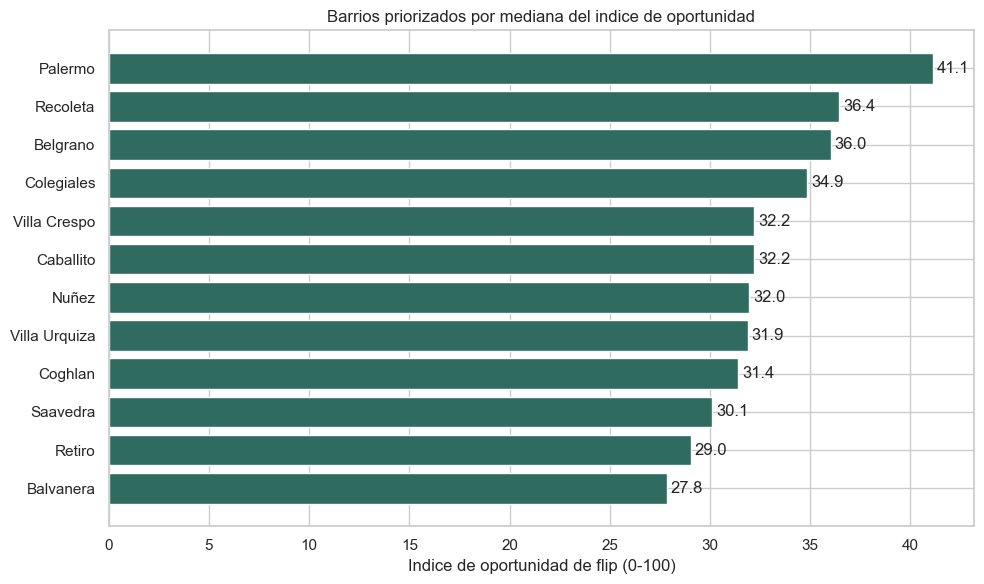

In [5]:
top_barrios = ranking_barrios.head(12).sort_values("indice_oportunidad_mediano")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_barrios[c("Barrio")],
    top_barrios["indice_oportunidad_mediano"],
    color="#2F6B5F",
)
ax.set_title("Barrios priorizados por mediana del indice de oportunidad")
ax.set_xlabel("Indice de oportunidad de flip (0-100)")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
plt.tight_layout()
plt.show()

**Decision habilitada:** concentrar el monitoreo y la construccion de comparables en los barrios mejor posicionados, sin descartar la revision individual.

**Validacion pendiente:** confirmar demanda efectiva, velocidad de venta, seguridad microterritorial, normativa y disponibilidad real del aviso.

## 5. Nivel propiedad: que avisos investigar primero

El ranking conserva solamente propiedades con descuento positivo y al menos cinco comparables. Una posicion alta indica mejor combinacion de señales disponibles, no una ganancia asegurada.

In [6]:
columnas_propiedad = [
    c("ID_registro"), c("Barrio"), c("Calle"), c("Altura"), c("Tipo_Unidad"),
    c("Ambientes"), c("Estado"), c("Precio"), c("Sup_Total_m2"), "Precio_m2",
    "Precio_m2_comparable", "Subvaluacion_%", "Indice_accesibilidad",
    "N_comparables", "Indice_oportunidad_flip", c("Link"),
]

ranking_propiedades = (
    work.loc[work["Es_oportunidad_elegible"], columnas_propiedad]
    .sort_values("Indice_oportunidad_flip", ascending=False)
    .reset_index(drop=True)
)
ranking_propiedades.insert(0, "ranking", np.arange(1, len(ranking_propiedades) + 1))
ranking_propiedades["validacion_requerida"] = (
    "Precio de cierre, estado real, presupuesto de obra, gastos, impuestos y plazo de reventa"
)

ranking_propiedades.to_csv(
    DATA_PROCESSED / "ranking_oportunidades_propiedades.csv",
    index=False,
    encoding="utf-8-sig",
)
display(ranking_propiedades.head(20).round(2))

,ranking,sintetica_id_registro,enriquecida_Barrio,original_Calle,original_Altura,imputada_Tipo_Unidad,imputada_Ambientes,imputada_Estado,imputada_Precio,imputada_Sup_Total_m2,Precio_m2,Precio_m2_comparable,Subvaluacion_%,Indice_accesibilidad,N_comparables,Indice_oportunidad_flip,original_Link,validacion_requerida
0,1,7322,Palermo,Bulnes,400.00,Departamento,2,Bueno,"70,000.00",57.00,"1,228.07","2,725.00",54.93,0.81,103,96.12,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
1,2,7318,Palermo,Bulnes,100.00,Departamento,4,A Refaccionar,"125,000.00",80.00,"1,562.50","2,542.41",38.54,0.81,60,86.47,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
2,3,1054,Saavedra,SAAVEDRA,300.00,Departamento,3,Bueno,"69,000.00",51.00,"1,352.94","2,812.50",51.90,0.62,21,85.53,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
3,4,57,Palermo,ARAOZ,"2,400.00",Semipiso,4,A Refaccionar,"270,000.00",150.00,"1,800.00","2,923.08",38.42,0.71,11,84.50,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
4,5,3259,Belgrano,Echeverria,"2,600.00",Departamento,4,Bueno,"185,000.00",117.00,"1,581.20","2,802.82",43.59,0.76,31,84.47,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
5,6,2119,Palermo,Sánchez De Bustamante,400.00,Semipiso,3,Bueno,"139,000.00",79.00,"1,759.49","2,684.21",34.45,0.84,13,84.02,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
6,7,3070,Palermo,Santa Fe Av.,"3,500.00",Semipiso,4,Bueno,"215,000.00",110.77,"1,940.92","2,923.08",33.60,0.87,11,83.94,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
7,8,272,Palermo,ARENALES,"3,000.00",Departamento,4,Bueno,"150,000.00",90.00,"1,666.67","2,542.41",34.45,0.80,60,83.07,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
8,9,6910,Colegiales,CONDE,700.00,No disponible,2,Bueno,"76,000.00",40.00,"1,900.00","3,593.85",47.13,0.53,53,82.43,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."
9,10,984,Palermo,Charcas,"3,000.00",Departamento,2,Bueno,"74,000.00",43.00,"1,720.93","2,725.00",36.85,0.63,103,81.59,https://www.argenprop.com/departamento-en-vent...,"Precio de cierre, estado real, presupuesto de ..."


## 6. Evidencia estadistica

Se utilizan pruebas no parametricas porque el precio por m2 es asimetrico. Los p-values se corrigen con Holm-Bonferroni y se reportan tamanos de efecto. La significancia estadistica no implica causalidad ni relevancia economica.

In [7]:
ALPHA = 0.05


def holm_bonferroni(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values))
    running_max = 0
    for rank, idx in enumerate(order):
        current = (len(p_values) - rank) * p_values[idx]
        running_max = max(running_max, current)
        adjusted[idx] = min(running_max, 1)
    return adjusted


def kruskal_by_group(data, group, target, min_n=30):
    temp = data[[group, target]].replace([np.inf, -np.inf], np.nan).dropna()
    valid_levels = temp[group].value_counts()
    valid_levels = valid_levels[valid_levels >= min_n].index
    temp = temp[temp[group].isin(valid_levels)]
    groups = [g[target].to_numpy() for _, g in temp.groupby(group, observed=False)]
    statistic, p_value = stats.kruskal(*groups)
    k, n = len(groups), len(temp)
    effect = max((statistic - k + 1) / (n - k), 0)
    return statistic, p_value, effect, n, k


work["Dotacion_amenities"] = pd.qcut(
    work["Cantidad_amenities"].rank(method="first"),
    q=3,
    labels=["Baja", "Media", "Alta"],
)
work["Rango_accesibilidad"] = pd.qcut(
    work["Indice_accesibilidad"].rank(method="first"),
    q=4,
    labels=["Baja", "Media-baja", "Media-alta", "Alta"],
)
work["Rango_dist_subte"] = pd.cut(
    work[c("Dist_Subte_m")],
    bins=[0, 250, 500, 750, 1000, np.inf],
    labels=["0-250 m", "250-500 m", "500-750 m", "750-1000 m", "Mas de 1000 m"],
    include_lowest=True,
)

resultados = []


def add_result(hipotesis, test, statistic, p_value, effect, effect_name, n, groups):
    resultados.append({
        "hipotesis": hipotesis,
        "test": test,
        "estadistico": statistic,
        "p_value": p_value,
        "tamano_efecto": effect,
        "medida_efecto": effect_name,
        "n": n,
        "grupos": groups,
    })


for hypothesis, group, target in [
    ("Precio por m2 difiere entre barrios", c("Barrio"), "Precio_m2"),
    ("Accesibilidad difiere entre barrios", c("Barrio"), "Indice_accesibilidad"),
    ("Precio por m2 difiere por dotacion de amenities", "Dotacion_amenities", "Precio_m2"),
    ("Precio por m2 difiere por accesibilidad", "Rango_accesibilidad", "Precio_m2"),
    ("Precio por m2 difiere por distancia al subte", "Rango_dist_subte", "Precio_m2"),
    ("Oportunidad difiere entre clusters", c("Cluster"), "Indice_oportunidad_flip"),
]:
    statistic, p_value, effect, n, groups = kruskal_by_group(work, group, target)
    add_result(hypothesis, "Kruskal-Wallis", statistic, p_value, effect, "epsilon^2", n, groups)

counts = work[c("Barrio")].value_counts()
statistic, p_value = stats.chisquare(counts.values)
effect = np.sqrt(statistic / (counts.sum() * (len(counts) - 1)))
add_result(
    "La oferta no se distribuye uniformemente entre barrios",
    "Chi-cuadrado bondad de ajuste", statistic, p_value, effect, "w",
    int(counts.sum()), len(counts),
)

for hypothesis, flag in [
    ("El stock mejorable depende del barrio", "Estado_mejorable"),
    ("El descuento fuerte depende del barrio", "Descuento_fuerte"),
]:
    sample = work if flag == "Estado_mejorable" else work[work["N_comparables"] >= 5]
    table = pd.crosstab(sample[c("Barrio")], sample[flag])
    if flag == "Descuento_fuerte":
        table = table.loc[table.sum(axis=1) >= 30]
    statistic, p_value, _, _ = stats.chi2_contingency(table)
    n = int(table.to_numpy().sum())
    effect = np.sqrt(statistic / (n * (min(table.shape) - 1)))
    add_result(
        hypothesis, "Chi-cuadrado independencia", statistic, p_value,
        effect, "Cramers V", n, table.shape[0],
    )

rho, p_value = stats.spearmanr(work["Cantidad_amenities"], work["Precio_m2"])
add_result(
    "Amenities y precio por m2 estan asociados", "Spearman", rho, p_value,
    abs(rho), "|rho|", len(work), 2,
)

resultados_tests = pd.DataFrame(resultados)
resultados_tests["p_value_ajustado_holm"] = holm_bonferroni(resultados_tests["p_value"])
resultados_tests["decision"] = np.where(
    resultados_tests["p_value_ajustado_holm"] < ALPHA,
    "Se rechaza H0",
    "No se rechaza H0",
)
resultados_tests.to_csv(
    DATA_PROCESSED / "resultados_tests_estadisticos.csv",
    index=False,
    encoding="utf-8-sig",
)
display(resultados_tests.round(4))

,hipotesis,test,estadistico,p_value,tamano_efecto,medida_efecto,n,grupos,p_value_ajustado_holm,decision
0,Precio por m2 difiere entre barrios,Kruskal-Wallis,"2,212.97",0.00,0.30,epsilon^2,7164,44,0.00,Se rechaza H0
1,Accesibilidad difiere entre barrios,Kruskal-Wallis,"4,130.15",0.00,0.57,epsilon^2,7164,44,0.00,Se rechaza H0
2,Precio por m2 difiere por dotacion de amenities,Kruskal-Wallis,206.01,0.00,0.03,epsilon^2,7245,3,0.00,Se rechaza H0
3,Precio por m2 difiere por accesibilidad,Kruskal-Wallis,169.83,0.00,0.02,epsilon^2,7245,4,0.00,Se rechaza H0
4,Precio por m2 difiere por distancia al subte,Kruskal-Wallis,148.29,0.00,0.02,epsilon^2,7245,5,0.00,Se rechaza H0
5,Oportunidad difiere entre clusters,Kruskal-Wallis,868.66,0.00,0.12,epsilon^2,7245,6,0.00,Se rechaza H0
6,La oferta no se distribuye uniformemente entre...,Chi-cuadrado bondad de ajuste,"6,095.79",0.00,0.13,w,7245,48,0.00,Se rechaza H0
7,El stock mejorable depende del barrio,Chi-cuadrado independencia,121.10,0.00,0.13,Cramers V,7245,48,0.00,Se rechaza H0
8,El descuento fuerte depende del barrio,Chi-cuadrado independencia,54.80,0.05,0.09,Cramers V,6381,40,0.05,Se rechaza H0
9,Amenities y precio por m2 estan asociados,Spearman,0.19,0.00,0.19,|rho|,7245,2,0.00,Se rechaza H0


### Lectura para el negocio

- El barrio explica diferencias sustantivas de precio por m2 y accesibilidad: la busqueda debe comenzar territorialmente.
- El stock mejorable y los descuentos no se distribuyen igual entre barrios: existen zonas con mayor concentracion de casos para investigar.
- Amenities, accesibilidad y distancia al subte presentan asociaciones estadisticas, pero sus tamanos de efecto sobre precio son bajos; no deben usarse en forma aislada.
- El indice cambia entre clusters, lo que respalda usar la segmentacion como contexto, no como veredicto sobre una propiedad.

## 7. Aporte del modelo predictivo

El notebook `10_Prediccion.ipynb` compara Ridge y Random Forest sobre precios USD observados. La division train/test se realiza por ubicacion para evitar que propiedades del mismo edificio aparezcan en ambos conjuntos. La imputacion se ajusta solamente con train.

Las metricas siguientes corresponden a la ejecucion documentada en ese notebook.

In [8]:
metricas_modelos = pd.DataFrame([
    {
        "modelo": "Ridge baseline",
        "MAE_USD": 49138,
        "RMSE_USD": 104604,
        "MedAE_USD": 23551,
        "MAPE_pct": 25.04,
        "R2": 0.59,
    },
    {
        "modelo": "Random Forest",
        "MAE_USD": 41337,
        "RMSE_USD": 90446,
        "MedAE_USD": 19477,
        "MAPE_pct": 21.13,
        "R2": 0.69,
    },
])
display(metricas_modelos)

validacion_repetida = pd.DataFrame([
    {
        "modelo": "Ridge baseline",
        "MAE_promedio_USD": 50504,
        "MAE_desvio_USD": 5091,
        "MAPE_promedio_pct": 25.15,
        "R2_promedio": 0.15,
        "R2_desvio": 0.49,
    },
    {
        "modelo": "Random Forest",
        "MAE_promedio_USD": 40409,
        "MAE_desvio_USD": 3739,
        "MAPE_promedio_pct": 20.22,
        "R2_promedio": 0.74,
        "R2_desvio": 0.02,
    },
])
display(validacion_repetida)

,modelo,MAE_USD,RMSE_USD,MedAE_USD,MAPE_pct,R2
0,Ridge baseline,49138,104604,23551,25.04,0.59
1,Random Forest,41337,90446,19477,21.13,0.69


,modelo,MAE_promedio_USD,MAE_desvio_USD,MAPE_promedio_pct,R2_promedio,R2_desvio
0,Ridge baseline,50504,5091,25.15,0.15,0.49
1,Random Forest,40409,3739,20.22,0.74,0.02


**Decision habilitada:** usar Random Forest como segunda opinion para detectar publicaciones alejadas del valor esperado segun sus atributos.

**Uso incorrecto:** interpretar la prediccion como precio futuro de reventa o como tasacion profesional.

**Validacion pendiente:** revisar manualmente los residuos, especialmente en propiedades premium, y contrastar contra comparables recientes y precios de cierre.

## 8. Recomendaciones para maximizar oportunidades detectadas

1. **Buscar primero por barrio.** Concentrar monitoreo en zonas con score alto, suficiente oferta y una cantidad minima de oportunidades comparables.
2. **Ordenar propiedades, no decidir automaticamente.** El ranking reduce el universo; la compra requiere inspeccion, presupuesto y analisis legal.
3. **Priorizar descuento defendible.** Exigir al menos cinco comparables y verificar que sean realmente equivalentes en ubicacion, estado y calidad.
4. **Cruzar descuento con estado mejorable.** Una propiedad barata sin margen de mejora o con problemas estructurales puede destruir valor.
5. **Adaptar las mejoras al barrio.** La prima asociada a amenities varia territorialmente; no toda mejora recupera su costo.
6. **Usar el modelo como alerta.** Una publicacion por debajo de la estimacion merece revision, pero el residuo no equivale a ganancia.
7. **Aplicar un filtro financiero final.** Incorporar precio negociado, obra, honorarios, impuestos, expensas durante la tenencia y plazo de salida.

## 9. Limitaciones

- Precios de publicacion, no precios efectivos de cierre.
- Corte transversal sin historial de cambios ni dias en mercado.
- Sin costos reales de obra, impuestos, comisiones, financiacion ni mantenimiento.
- El estado publicado puede no representar la condicion estructural real.
- Los comparables se definen con variables disponibles y pueden omitir calidad constructiva o micro-ubicacion.
- Los tests muestran asociaciones y diferencias, no causalidad.
- El indice de oportunidad es una herramienta de priorizacion, no una estimacion de ROI.

## 10. Camino a produccion

Una implementacion operativa requeriria:

1. scraping programado con control de cambios y cumplimiento de terminos de uso;
2. almacenamiento historico de publicaciones y versiones de precio;
3. validaciones automaticas de calidad y geocodificacion;
4. recalculo periodico de comparables, scores y predicciones;
5. publicacion del dataset curado en Power BI Service con actualizacion programada;
6. alertas para nuevas propiedades que superen umbrales de oportunidad;
7. registro manual de visitas, presupuestos, precio negociado y resultado de cada operacion;
8. monitoreo de error y reentrenamiento del modelo.

Para evolucionar hacia ROI esperado se deben incorporar, como minimo:

`ROI = (precio de venta esperado - precio de compra negociado - obra - gastos totales) / capital invertido`

Hasta contar con esas variables, el producto debe comunicar **oportunidad analitica para investigar**, nunca **rentabilidad confirmada**.

In [9]:
print("Archivos ejecutivos generados:")
for filename in [
    "ranking_barrios_oportunidad.csv",
    "ranking_oportunidades_propiedades.csv",
    "resultados_tests_estadisticos.csv",
]:
    path = DATA_PROCESSED / filename
    print(f"- {path.relative_to(ROOT)} ({path.stat().st_size / 1024:,.1f} KB)")

Archivos ejecutivos generados:
- data\processed\ranking_barrios_oportunidad.csv (6.2 KB)
- data\processed\ranking_oportunidades_propiedades.csv (1,058.5 KB)
- data\processed\resultados_tests_estadisticos.csv (1.7 KB)
